# Homework 5

# Задача №1 - Можете ли вы отличить сорняки от рассады?

Теперь приступим к задаче классификации на картинках. Реализуйте программу, которая определяет тип рассады на изображении. 

Для того, чтобы определить характерные особенности каждого типа рассады, у вас есть train. Train это папка, в которой картинки уже классифицированы и лежат в соответствующих папках. Исходя из этой информации можете найти признаки, присущие конкретному растению.

Проверка вашего решения будет на происходить на test. В папке test уже нет метки класса для каждой картинки. 

[Ссылка на Яндекс-диск](https://yadi.sk/d/0Zzp0klXT0iRmA), все картинки тут.

Примеры изображений для теста:
<table><tr>
    <td> <img src="https://i.ibb.co/tbqR37m/fhj.png" alt="Drawing" style="width: 200px;"/> </td>
    <td> <img src="https://i.ibb.co/6yL3Wmt/sfg.png" alt="Drawing" style="width: 200px;"/> </td>
    <td> <img src="https://i.ibb.co/pvn7NvF/asd.png" alt="Drawing" style="width: 200px;"/> </td>
</tr></table>

In [1]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from glob import glob
import os
from tqdm import tqdm
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt


In [21]:
def get_sift_descriptors(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_COLOR_RGB)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    mask = cv2.inRange(img, (35, 50, 50), (85, 255, 255))
    gray_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)*mask
    sift = cv2.SIFT_create()
    _, descriptors = sift.detectAndCompute(gray_img, None) 
    return descriptors

def build_feature_vocabilary(train_image_paths, features_size):
    all_descriptors = []
    
    for path in tqdm(train_image_paths, desc="Extracting SIFT features"):
        descriptors = get_sift_descriptors(path)
        all_descriptors.append(descriptors)
    all_descriptors = np.vstack(all_descriptors)

    kmeans = KMeans(n_clusters=features_size, random_state=42)
    kmeans.fit(all_descriptors)
    return kmeans

def create_features(image_path, kmeans, features_size):
    descriptors = get_sift_descriptors(image_path)
    if descriptors is None:
        return np.zeros(features_size)
    
    visual_words = kmeans.predict(descriptors)
    
    hist, _ = np.histogram(visual_words, bins=features_size, range=(0, features_size))
    hist = hist.astype(np.float32)
    if hist.sum() != 0:
        hist /= hist.sum()
    return hist

def train_plant_classifier(train_dir, features_size):
    categories = sorted(os.listdir(train_dir))
    image_paths = []
    labels = []
    
    for label, category in enumerate(categories):
        category_path = os.path.join(train_dir, category)
        for img_path in glob(os.path.join(category_path, "*.png")):
            image_paths.append(img_path)
            labels.append(label)
    
    print("Building visual vocabulary...")
    kmeans = build_feature_vocabilary(image_paths, features_size)
    
    print("Creating features...")
    X_train = []
    for path in tqdm(image_paths, desc="Processing training images"):
        feature_vector = create_features(path, kmeans, features_size)
        X_train.append(feature_vector)
    
    X_train = np.array(X_train)
    y_train = np.array(labels)
    
    print("Training classifier...")
    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', LogisticRegression())
    ])
    clf.fit(X_train, y_train)
    
    return clf, kmeans, categories

def test_plant_classifier(test_dir, clf, kmeans, class_names, features_size):
    test_images = []
    test_images.extend(glob(os.path.join(test_dir, "*.png")))
    
    print(f"Testing {len(test_images)} images...")
    preds = []
    results = []
    for img_path in tqdm(test_images, desc="Processing test images"):
        feature_vector = create_features(img_path, kmeans, features_size)
        
        probas = clf.predict_proba([feature_vector])[0]
        
        top_class_idx = np.argmax(probas)
        top_class_name = class_names[top_class_idx]
        top_confidence = probas[top_class_idx]
        

        preds.append(top_class_idx)
        results.append({
            'image_path': img_path,
            'predictions': list(zip(class_names, probas)),
            'top_class': top_class_name + str(top_class_idx),
            'confidence': top_confidence
        })
    
    return results, preds

train_dir = "plants\\train"  
test_dir = "plants\\test"
features_size = 10
print("=== Training ===")
classifier, visual_vocab, class_names = train_plant_classifier(train_dir, features_size=features_size)

print("\n=== Testing ===")
test_results, preds = test_plant_classifier(test_dir, classifier, visual_vocab, class_names, features_size=features_size)
y_test = [1, 1, 2, 2, 1, 1, 3, 4, 2, 1, 2, 2, 1, 4, 3, 4, 3, 4, 1, 4, 3, 3, 4, 2, 4, 3, 3, 2, 4, 4, 1, 3, 1, 1, 2, 3, 4, 3, 2, 2]
y_test = np.array(y_test) - 1
print("\n=== Test Results ===")
for result in test_results:
    print(f"\nImage: {result['image_path'].split('\\')[-1]}")
    print(f"Predicted class: {result['top_class']} (confidence: {result['confidence']:.2f})")
    print("All predictions:")
    for class_name, prob in sorted(result['predictions'], key=lambda x: -x[1]):
        print(f"  {class_name}: {prob:.4f}")

print("\n=== Accuracy ===")
print(accuracy_score(y_test, preds))

=== Training ===
Building visual vocabulary...


Extracting SIFT features:   0%|          | 0/20 [00:00<?, ?it/s]

Extracting SIFT features: 100%|██████████| 20/20 [00:03<00:00,  6.10it/s]


Creating features...


Processing training images: 100%|██████████| 20/20 [00:03<00:00,  6.27it/s]


Training classifier...

=== Testing ===
Testing 40 images...


Processing test images: 100%|██████████| 40/40 [00:07<00:00,  5.61it/s]


=== Test Results ===

Image: ada.png
Predicted class: Loose Silky-bent0 (confidence: 0.96)
All predictions:
  Loose Silky-bent: 0.9589
  Maize: 0.0244
  Scentless Mayweed: 0.0148
  Small-flowered Cranesbill: 0.0019

Image: asd.png
Predicted class: Loose Silky-bent0 (confidence: 0.93)
All predictions:
  Loose Silky-bent: 0.9262
  Scentless Mayweed: 0.0378
  Maize: 0.0296
  Small-flowered Cranesbill: 0.0065

Image: asg.png
Predicted class: Maize1 (confidence: 0.73)
All predictions:
  Maize: 0.7332
  Small-flowered Cranesbill: 0.2184
  Loose Silky-bent: 0.0416
  Scentless Mayweed: 0.0068

Image: cbn.png
Predicted class: Maize1 (confidence: 0.47)
All predictions:
  Maize: 0.4736
  Scentless Mayweed: 0.2741
  Small-flowered Cranesbill: 0.2146
  Loose Silky-bent: 0.0377

Image: dfg.png
Predicted class: Loose Silky-bent0 (confidence: 0.99)
All predictions:
  Loose Silky-bent: 0.9946
  Maize: 0.0047
  Scentless Mayweed: 0.0004
  Small-flowered Cranesbill: 0.0003

Image: dgf.png
Predicted clas

# Задача №2 - Собери пазл (2.0).

Даны кусочки изображения, ваша задача склеить пазл в исходную картинку. 

Условия:
* Дано исходное изображение для проверки, использовать собранное изображение в самом алгоритме нельзя;
* Картинки имеют друг с другом пересечение;
* После разрезки кусочки пазлов не были повернуты или отражены;
* НЕЛЬЗЯ выбрать опорную картинку для сбора пазла, как это было в homework 3
* В процессе проверки решения пазлы могут быть перемешаны, т.е. порядок пазлов в проверке может отличаться от исходного 

Изображения расположены по [ссылке](https://disk.yandex.ru/d/XtpawH1sV9UDlg).

Примеры изображений:
<img src="puzzle/su_fighter.jpg" alt="Drawing" style="width: 300px;"/>
<table><tr>
    <td> <img src="puzzle/su_fighter_shuffle/0.jpg" alt="Drawing" style="width: 200px;"/> </td>
    <td> <img src="puzzle/su_fighter_shuffle/1.jpg" alt="Drawing" style="width: 200px;"/> </td>
    <td> <img src="puzzle/su_fighter_shuffle/2.jpg" alt="Drawing" style="width: 200px;"/> </td>
    <td> <img src="puzzle/su_fighter_shuffle/3.jpg" alt="Drawing" style="width: 200px;"/> </td>
</tr></table>

Код ниже одинаковый во всех блоках, просто работал над разными пазлами. Сделал это для удобства проверки, уж очень долго собирается дом (и то не полностью). Плохо срабатывает на облаках (надо дотошно подбирать параметры, а у меня на это уже нет сил)

can't solve puzzle


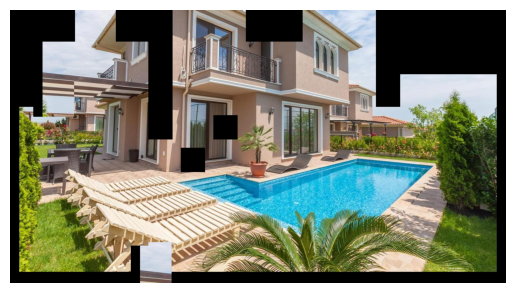

In [ ]:
def apply_transformation(transform_mat, points):
    transformed_points = (transform_mat @ points.T).T
    transformed_points = np.divide(transformed_points.T, transformed_points[:, 2]).T
    return transformed_points

def construct_offset_transformation(x):
    transformation = np.eye(3)
    transformation[:2, 2] = x
    return transformation

def find_offset_ransac(points, transformed_points):
    best_offset = None
    best_loss = np.inf
    loss_f = lambda x1, x2: np.linalg.norm(x1 - x2)
    for point, transformed_point in zip(points, transformed_points):
        offset = (transformed_point - point)[:2]
        transformation = construct_offset_transformation(offset)
        tmp = apply_transformation(transformation, points)
        tmp_loss = loss_f(tmp, transformed_points)
        if tmp_loss < best_loss:
            best_loss = tmp_loss
            best_offset = offset
    return best_offset

def get_shift(first, second):

    nfetures = first.size // second.size * 500

    hyp_params2 = dict(
    nfeatures = 500,
    nOctaveLayers = 11,
    contrastThreshold = 0.03,
    edgeThreshold = 10,
    sigma = 1.7) 

    hyp_params1 = dict(
    nfeatures = nfetures,
    nOctaveLayers = 11,
    contrastThreshold = 0.03,
    edgeThreshold = 10,
    sigma = 1.7) 
    sift2 = cv2.SIFT_create(**hyp_params2)
    sift1 = cv2.SIFT_create(**hyp_params1)
    
    FLANN_INDEX_KDTREE = 2
    index_params = dict(algorithm=2, trees=15)
    search_params = dict(checks=150)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    kp1, des1 = sift1.detectAndCompute(first, None)
    kp2, des2 = sift2.detectAndCompute(second, None)

    if des2 is None or des1 is  None:
        return None
    
    try:
        matches = flann.knnMatch(des1, des2, k=2)
        ratio_thresh = 0.2
        good_matches = []
        for m, n in matches:
            if m.distance < ratio_thresh * n.distance:
                good_matches.append(m)
    except:
        return None
    if len(good_matches) == 0:
        return None
    points = np.array([[kp1[m.queryIdx].pt[1], kp1[m.queryIdx].pt[0], 1] for m in good_matches])
    transformed_points = np.array([[kp2[m.trainIdx ].pt[1], kp2[m.trainIdx ].pt[0], 1] for m in good_matches])
    
    shift = find_offset_ransac(transformed_points, points)
    if shift is not None:
        shift[0] = round(shift[0])
        shift[1] = round(shift[1])
    return shift
    

    
def are_shifted(first, second):
    shift = get_shift(first, second)
    if shift is None:
        return False
    return True


def stitch_images_right_down(left, right, shift):
    new_shape = [max(left.shape[0], right.shape[0] + shift[0]), max(left.shape[1], right.shape[1] + shift[1]), 3]
    new_image = np.zeros(shape=new_shape)
    new_image[0:left.shape[0], 0:left.shape[1], :] = left
    new_image[shift[0]:right.shape[0]+shift[0], shift[1]:right.shape[1]+shift[1], :] = right
    new_image = new_image.astype(np.uint8)
    return new_image

def stitch_images(first, second):
    shift = get_shift(first, second)
    if shift is None:
        return None
    shift = np.array(shift, dtype=np.int32)
    if shift[0] >= 0  and shift[1] >= 0:
        result = stitch_images_right_down(first, second, shift)
    elif shift[0] >= 0 and shift[1] < 0:
        shift[1] *= -1
        first = np.pad(first,((0, 0), (shift[1],0), (0, 0)))
        shift[1] = 0
        result = stitch_images_right_down(first, second, shift)
    elif shift[0] < 0 and shift[1] >= 0:
        shift[0] *= -1
        first = np.pad(first,((shift[0], 0), (0,0), (0, 0)))
        shift[0] = 0
        result = stitch_images_right_down(first, second, shift)
    elif shift[0] < 0 and shift[1] < 0:
        shift[0] *= -1
        shift[1] *= -1
        first = np.pad(first,((shift[0], 0), (shift[1],0), (0, 0)))
        shift[0] = 0
        shift[1] = 0
        result = stitch_images_right_down(first, second, shift)
    return result


image_paths = []
# puzzle_dir = 'puzzle/su_fighter_shuffle' # (выполняется около нескольких секунд)
# puzzle_dir = 'puzzle/china_shuffle' # (выполняется около нескольких минут)
puzzle_dir = 'puzzle/home_shuffle' # не работает (выполняется около часа)
image_paths.extend(glob(os.path.join(puzzle_dir, "*.jpg")))

images = [cv2.imread(image_path) for image_path in image_paths]

index = [*range(len(images))]
base_image = images[0]
index.remove(0)

while len(index) > 0:
    breaked = False
    # cv2.imshow('base_image', base_image)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()
    for i in index:
        img = images[i]
        if are_shifted(base_image, img):
            breaked = True
            base_image = stitch_images(base_image, img )
            index.remove(i)
            break
    if breaked:
        continue
    else:
        print("can't solve puzzle")
        break


base_image = cv2.cvtColor(base_image, cv2.COLOR_BGR2RGB)
plt.imshow(base_image)
plt.axis('off')
plt.show()

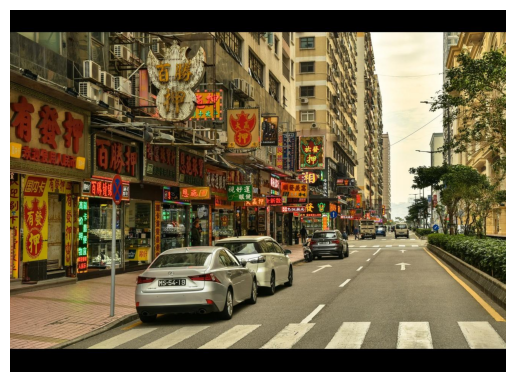

In [19]:
def apply_transformation(transform_mat, points):
    transformed_points = (transform_mat @ points.T).T
    transformed_points = np.divide(transformed_points.T, transformed_points[:, 2]).T
    return transformed_points

def construct_offset_transformation(x):
    transformation = np.eye(3)
    transformation[:2, 2] = x
    return transformation

def find_offset_ransac(points, transformed_points):
    best_offset = None
    best_loss = np.inf
    loss_f = lambda x1, x2: np.linalg.norm(x1 - x2)
    for point, transformed_point in zip(points, transformed_points):
        offset = (transformed_point - point)[:2]
        transformation = construct_offset_transformation(offset)
        tmp = apply_transformation(transformation, points)
        tmp_loss = loss_f(tmp, transformed_points)
        if tmp_loss < best_loss:
            best_loss = tmp_loss
            best_offset = offset
    return best_offset

def get_shift(first, second):

    nfetures = first.size // second.size * 500

    hyp_params2 = dict(
    nfeatures = 500,
    nOctaveLayers = 11,
    contrastThreshold = 0.03,
    edgeThreshold = 10,
    sigma = 1.7) 

    hyp_params1 = dict(
    nfeatures = nfetures,
    nOctaveLayers = 11,
    contrastThreshold = 0.03,
    edgeThreshold = 10,
    sigma = 1.7) 
    sift2 = cv2.SIFT_create(**hyp_params2)
    sift1 = cv2.SIFT_create(**hyp_params1)
    
    FLANN_INDEX_KDTREE = 2
    index_params = dict(algorithm=2, trees=15)
    search_params = dict(checks=150)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    kp1, des1 = sift1.detectAndCompute(first, None)
    kp2, des2 = sift2.detectAndCompute(second, None)

    if des2 is None or des1 is  None:
        return None
    
    try:
        matches = flann.knnMatch(des1, des2, k=2)
        ratio_thresh = 0.2
        good_matches = []
        for m, n in matches:
            if m.distance < ratio_thresh * n.distance:
                good_matches.append(m)
    except:
        return None
    if len(good_matches) == 0:
        return None
    points = np.array([[kp1[m.queryIdx].pt[1], kp1[m.queryIdx].pt[0], 1] for m in good_matches])
    transformed_points = np.array([[kp2[m.trainIdx ].pt[1], kp2[m.trainIdx ].pt[0], 1] for m in good_matches])
    
    shift = find_offset_ransac(transformed_points, points)
    if shift is not None:
        shift[0] = round(shift[0])
        shift[1] = round(shift[1])
    return shift
    

    
def are_shifted(first, second):
    shift = get_shift(first, second)
    if shift is None:
        return False
    return True


def stitch_images_right_down(left, right, shift):
    new_shape = [max(left.shape[0], right.shape[0] + shift[0]), max(left.shape[1], right.shape[1] + shift[1]), 3]
    new_image = np.zeros(shape=new_shape)
    new_image[0:left.shape[0], 0:left.shape[1], :] = left
    new_image[shift[0]:right.shape[0]+shift[0], shift[1]:right.shape[1]+shift[1], :] = right
    new_image = new_image.astype(np.uint8)
    return new_image

def stitch_images(first, second):
    shift = get_shift(first, second)
    if shift is None:
        return None
    shift = np.array(shift, dtype=np.int32)
    if shift[0] >= 0  and shift[1] >= 0:
        result = stitch_images_right_down(first, second, shift)
    elif shift[0] >= 0 and shift[1] < 0:
        shift[1] *= -1
        first = np.pad(first,((0, 0), (shift[1],0), (0, 0)))
        shift[1] = 0
        result = stitch_images_right_down(first, second, shift)
    elif shift[0] < 0 and shift[1] >= 0:
        shift[0] *= -1
        first = np.pad(first,((shift[0], 0), (0,0), (0, 0)))
        shift[0] = 0
        result = stitch_images_right_down(first, second, shift)
    elif shift[0] < 0 and shift[1] < 0:
        shift[0] *= -1
        shift[1] *= -1
        first = np.pad(first,((shift[0], 0), (shift[1],0), (0, 0)))
        shift[0] = 0
        shift[1] = 0
        result = stitch_images_right_down(first, second, shift)
    return result


image_paths = []
# puzzle_dir = 'puzzle/su_fighter_shuffle' # (выполняется около нескольких секунд)
puzzle_dir = 'puzzle/china_shuffle' # (выполняется около нескольких минут)
# puzzle_dir = 'puzzle/home_shuffle' # не работает (выполняется около часа)
image_paths.extend(glob(os.path.join(puzzle_dir, "*.jpg")))

images = [cv2.imread(image_path) for image_path in image_paths]

index = [*range(len(images))]
base_image = images[0]
index.remove(0)

while len(index) > 0:
    breaked = False
    # cv2.imshow('base_image', base_image)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()
    for i in index:
        img = images[i]
        if are_shifted(base_image, img):
            breaked = True
            base_image = stitch_images(base_image, img )
            index.remove(i)
            break
    if breaked:
        continue
    else:
        print("can't solve puzzle")
        break


base_image = cv2.cvtColor(base_image, cv2.COLOR_BGR2RGB)
plt.imshow(base_image)
plt.axis('off')
plt.show()

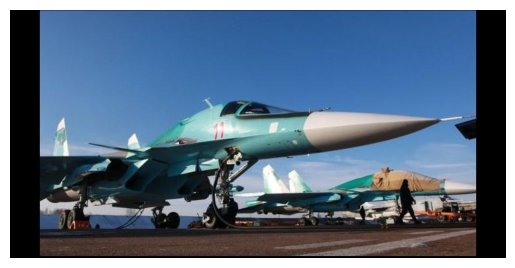

In [20]:
def apply_transformation(transform_mat, points):
    transformed_points = (transform_mat @ points.T).T
    transformed_points = np.divide(transformed_points.T, transformed_points[:, 2]).T
    return transformed_points

def construct_offset_transformation(x):
    transformation = np.eye(3)
    transformation[:2, 2] = x
    return transformation

def find_offset_ransac(points, transformed_points):
    best_offset = None
    best_loss = np.inf
    loss_f = lambda x1, x2: np.linalg.norm(x1 - x2)
    for point, transformed_point in zip(points, transformed_points):
        offset = (transformed_point - point)[:2]
        transformation = construct_offset_transformation(offset)
        tmp = apply_transformation(transformation, points)
        tmp_loss = loss_f(tmp, transformed_points)
        if tmp_loss < best_loss:
            best_loss = tmp_loss
            best_offset = offset
    return best_offset

def get_shift(first, second):

    nfetures = first.size // second.size * 500

    hyp_params2 = dict(
    nfeatures = 500,
    nOctaveLayers = 11,
    contrastThreshold = 0.03,
    edgeThreshold = 10,
    sigma = 1.7) 

    hyp_params1 = dict(
    nfeatures = nfetures,
    nOctaveLayers = 11,
    contrastThreshold = 0.03,
    edgeThreshold = 10,
    sigma = 1.7) 
    sift2 = cv2.SIFT_create(**hyp_params2)
    sift1 = cv2.SIFT_create(**hyp_params1)
    
    FLANN_INDEX_KDTREE = 2
    index_params = dict(algorithm=2, trees=15)
    search_params = dict(checks=150)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    kp1, des1 = sift1.detectAndCompute(first, None)
    kp2, des2 = sift2.detectAndCompute(second, None)

    if des2 is None or des1 is  None:
        return None
    
    try:
        matches = flann.knnMatch(des1, des2, k=2)
        ratio_thresh = 0.2
        good_matches = []
        for m, n in matches:
            if m.distance < ratio_thresh * n.distance:
                good_matches.append(m)
    except:
        return None
    if len(good_matches) == 0:
        return None
    points = np.array([[kp1[m.queryIdx].pt[1], kp1[m.queryIdx].pt[0], 1] for m in good_matches])
    transformed_points = np.array([[kp2[m.trainIdx ].pt[1], kp2[m.trainIdx ].pt[0], 1] for m in good_matches])
    
    shift = find_offset_ransac(transformed_points, points)
    if shift is not None:
        shift[0] = round(shift[0])
        shift[1] = round(shift[1])
    return shift
    

    
def are_shifted(first, second):
    shift = get_shift(first, second)
    if shift is None:
        return False
    return True


def stitch_images_right_down(left, right, shift):
    new_shape = [max(left.shape[0], right.shape[0] + shift[0]), max(left.shape[1], right.shape[1] + shift[1]), 3]
    new_image = np.zeros(shape=new_shape)
    new_image[0:left.shape[0], 0:left.shape[1], :] = left
    new_image[shift[0]:right.shape[0]+shift[0], shift[1]:right.shape[1]+shift[1], :] = right
    new_image = new_image.astype(np.uint8)
    return new_image

def stitch_images(first, second):
    shift = get_shift(first, second)
    if shift is None:
        return None
    shift = np.array(shift, dtype=np.int32)
    if shift[0] >= 0  and shift[1] >= 0:
        result = stitch_images_right_down(first, second, shift)
    elif shift[0] >= 0 and shift[1] < 0:
        shift[1] *= -1
        first = np.pad(first,((0, 0), (shift[1],0), (0, 0)))
        shift[1] = 0
        result = stitch_images_right_down(first, second, shift)
    elif shift[0] < 0 and shift[1] >= 0:
        shift[0] *= -1
        first = np.pad(first,((shift[0], 0), (0,0), (0, 0)))
        shift[0] = 0
        result = stitch_images_right_down(first, second, shift)
    elif shift[0] < 0 and shift[1] < 0:
        shift[0] *= -1
        shift[1] *= -1
        first = np.pad(first,((shift[0], 0), (shift[1],0), (0, 0)))
        shift[0] = 0
        shift[1] = 0
        result = stitch_images_right_down(first, second, shift)
    return result


image_paths = []
puzzle_dir = 'puzzle/su_fighter_shuffle' # (выполняется около нескольких секунд)
# puzzle_dir = 'puzzle/china_shuffle' # (выполняется около нескольких минут)
# puzzle_dir = 'puzzle/home_shuffle' # не работает (выполняется около часа)
image_paths.extend(glob(os.path.join(puzzle_dir, "*.jpg")))

images = [cv2.imread(image_path) for image_path in image_paths]

index = [*range(len(images))]
base_image = images[0]
index.remove(0)

while len(index) > 0:
    breaked = False
    # cv2.imshow('base_image', base_image)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()
    for i in index:
        img = images[i]
        if are_shifted(base_image, img):
            breaked = True
            base_image = stitch_images(base_image, img )
            index.remove(i)
            break
    if breaked:
        continue
    else:
        print("can't solve puzzle")
        break


base_image = cv2.cvtColor(base_image, cv2.COLOR_BGR2RGB)
plt.imshow(base_image)
plt.axis('off')
plt.show()